# Hoạt động 1 - Hồi quy tuyến tính đơn bằng tay (Simple Linear Regression by Hand)

Bối cảnh: dự báo điểm thi (`exam_score`) từ số giờ học (`study_hours`).

Mô hình:

$$y_i = \beta_0 + \beta_1x_i + \varepsilon_i$$

Trong đó:

- $\beta_0$: hệ số chặn (intercept), giá trị kỳ vọng của y khi x = 0.
- $\beta_1$: hệ số dốc (slope), mức thay đổi trung bình của y khi x tăng 1 đơn vị.
- $\varepsilon_i$: sai số ngẫu nhiên (random error).

Ước lượng bằng OLS - phương pháp bình phương tối thiểu thông thường (Ordinary Least Squares) cho SLR:

$$\hat{\beta}_1 = \frac{\sum_i(x_i-\bar{x})(y_i-\bar{y})}{\sum_i(x_i-\bar{x})^2}$$

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$$

In [47]:
#%pip install statsmodels

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("datasets/activity_01_slr_hand_calculation.csv")
print("Kích thước dữ liệu:", df.shape)
display(df.head())
display(df.describe())
display(df.info())

Kích thước dữ liệu: (12, 3)


,student_id,study_hours,exam_score
0,1,1.0,51.0
1,2,2.0,55.0
2,3,2.5,57.0
3,4,3.0,61.0
4,5,3.5,64.0


,student_id,study_hours,exam_score
count,12.000000,12.000000,12.000000
mean,6.500000,4.625000,68.916667
std,3.605551,2.469128,12.413031
min,1.000000,1.000000,51.000000
25%,3.750000,2.875000,60.000000
50%,6.500000,4.250000,67.000000
75%,9.250000,6.250000,77.250000
max,12.000000,9.000000,90.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   12 non-null     int64  
 1   study_hours  12 non-null     float64
 2   exam_score   12 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 416.0 bytes


None

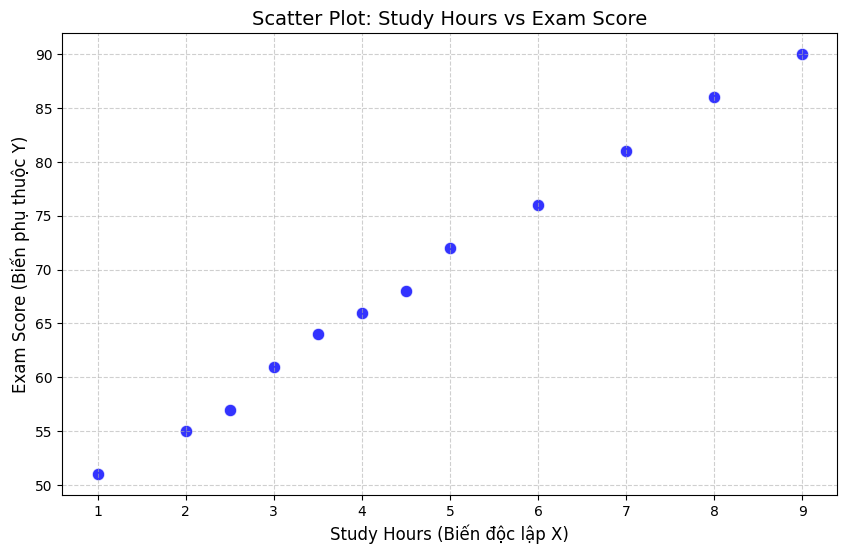

In [49]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='study_hours', y='exam_score', color='blue', s=80, alpha=0.8)

plt.title('Scatter Plot: Study Hours vs Exam Score', fontsize=14)
plt.xlabel('Study Hours (Biến độc lập X)', fontsize=12)
plt.ylabel('Exam Score (Biến phụ thuộc Y)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [50]:
x = df['study_hours'].to_numpy()
y = df['exam_score'].to_numpy()

xbar = x.mean()
ybar = y.mean()

x_centered = x - xbar
y_centered = y - ybar
print(f'xbar = {xbar:.3f}, ybar = {ybar:.3f}')

beta1 = np.sum(x_centered*y_centered)/np.sum(x_centered**2)
beta0 = ybar - beta1*xbar
print(f"intercept = {beta0:.3f}, slope = {beta1:.3f}")

table = pd.DataFrame({
    "x": x,
    "y": y,
    "x_minus_xbar": x_centered,
    "y_minus_ybar": y_centered,
    "cross_product":x_centered*y_centered,
    "x_centered_square":x_centered**2
})
table.head()


xbar = 4.625, ybar = 68.917
intercept = 45.701, slope = 5.020


,x,y,x_minus_xbar,y_minus_ybar,cross_product,x_centered_square
0,1.0,51.0,-3.625,-17.916667,64.947917,13.140625
1,2.0,55.0,-2.625,-13.916667,36.531250,6.890625
2,2.5,57.0,-2.125,-11.916667,25.322917,4.515625
3,3.0,61.0,-1.625,-7.916667,12.864583,2.640625
4,3.5,64.0,-1.125,-4.916667,5.531250,1.265625


In [51]:
predictY = beta0 + beta1*x
resid = y - predictY

SSE = np.sum(resid**2)
MSE_unbiased = SSE / (len(y) - 2)
RMSE = np.sqrt(np.mean(resid**2))  
MAE = np.mean(np.abs(resid))
SST = np.sum((y - ybar)**2)
R2 = 1 - SSE/SST

print(f'SSE/RSS = tổng bình phương phần dư = {SSE:.3f}')
print(f'MSE = sai số bình phương trung bình (chia n-2 cho ước lượng phương sai) = {MSE_unbiased:.3f}')
print(f'RMSE = căn sai số bình phương trung bình = {RMSE:.3f}')
print(f'MAE = sai số tuyệt đối trung bình = {MAE:.3f}')
print(f'R2 = hệ số xác định = {R2:.3f}')

SSE/RSS = tổng bình phương phần dư = 5.203
MSE = sai số bình phương trung bình (chia n-2 cho ước lượng phương sai) = 0.520
RMSE = căn sai số bình phương trung bình = 0.659
MAE = sai số tuyệt đối trung bình = 0.526
R2 = hệ số xác định = 0.997


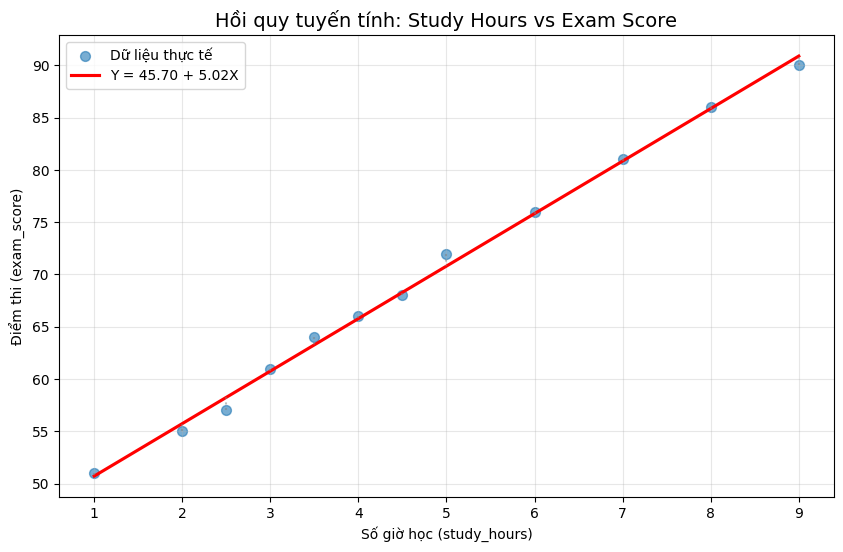

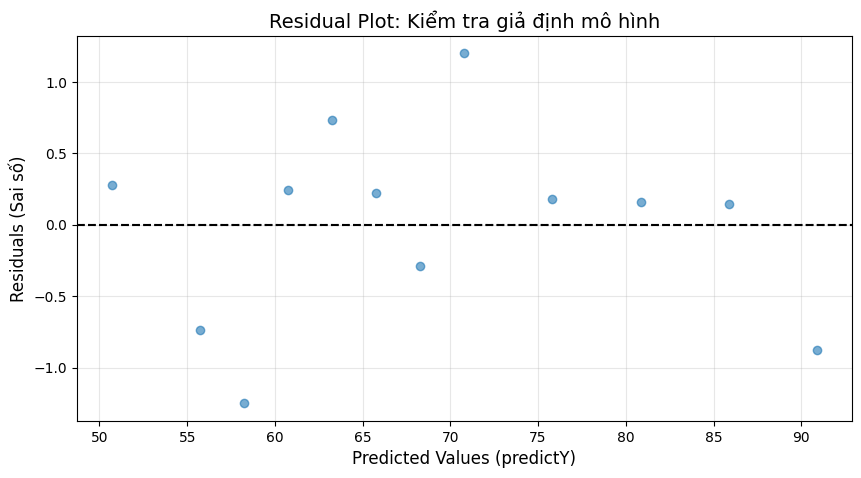

In [52]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='study_hours', y='exam_score', 
            scatter_kws={'s': 50, 'alpha': 0.6}, 
            line_kws={'color': 'red', 'label': f'Y = {beta0:.2f} + {beta1:.2f}X'},
            label='Dữ liệu thực tế', ci=None)

for xi, yi, pyi in zip(x, y, predictY):
    plt.plot([xi, xi], [yi, pyi], color='gray', linestyle=':', alpha=0.5)

plt.title('Hồi quy tuyến tính: Study Hours vs Exam Score', fontsize=14)
plt.xlabel('Số giờ học (study_hours)')
plt.ylabel('Điểm thi (exam_score)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


table["residual"] = y - predictY

plt.figure(figsize=(10, 5))

sns.residplot(
    x=predictY, 
    y=table['residual'].values, 
    lowess=False, 
    scatter_kws={'alpha': 0.6}
)

plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Plot: Kiểm tra giả định mô hình', fontsize=14)
plt.xlabel('Predicted Values (predictY)', fontsize=12)
plt.ylabel('Residuals (Sai số)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
print(f"1. Ý nghĩa Hệ số dốc (Slope):")
print(f"   Hệ số dốc cho biết khi số giờ học (x) tăng thêm 1 giờ, thì điểm thi dự kiến sẽ tăng trung bình khoảng {beta1:.2f} điểm.")
print(f"   Ví dụ: Nếu học thêm 1 giờ, điểm tăng thêm {beta1:.2f}; học thêm 2 giờ, điểm tăng thêm {2*beta1:.2f} điểm.")
print(f"   Lưu ý: Đây là giá trị trung bình (expected value). Thực tế có sai số ngẫu nhiên nên không phải ai học thêm cũng tăng đúng mức này.")

print(f"\n2. Ý nghĩa Hệ số chặn (Intercept):")
print(f"   Hệ số chặn ({beta0:.2f}) đại diện cho điểm số dự kiến khi số giờ học bằng 0.") 
print(f"   Về mặt toán học, nó giúp định vị điểm bắt đầu của đường thẳng. Tuy nhiên, cần cẩn trọng khi diễn giải vì x=0 thường nằm ngoài phạm vi quan sát của dữ liệu thực tế.")

print(f"\n3. Kiểm định phần dư (Residuals):")
print(f"   Biểu đồ Residual không còn pattern (quy luật) rõ rệt, cho thấy mô hình hồi quy tuyến tính là phù hợp.")
print(f"   Các giả định về tính ngẫu nhiên và phương sai không đổi (homoscedasticity) được thỏa mãn.")

print(f"\n4. Cảnh báo về Nhân quả (Causation):")
print(f"   Mô hình chỉ chỉ ra sự tương quan. Việc điểm tăng có thể do nhiều yếu tố khác (như nỗ lực cá nhân, độ khó đề thi).")
print(f"   Vì vậy, không nên dùng từ 'chắc chắn' mà nên dùng 'xu hướng trung bình'.")

print(f"\n5. Tại sao tổng phần dư thô (sum of residuals) bằng 0 và tại sao cần SSE?")
print(f"   => Trong phương pháp OLS, đường thẳng được tính toán để nằm 'chính giữa' các điểm dữ liệu.")
print(f"   => Điều này khiến tổng các sai số dương và sai số âm tự triệt tiêu lẫn nhau, dẫn đến tổng bằng 0.")
print(f"   => Vì tổng luôn bằng 0, nó không thể dùng để đánh giá mô hình tốt hay xấu.")
print(f"   => Do đó, ta phải dùng Tổng bình phương sai số (SSE). Việc bình phương giúp:")
print(f"      + Biến mọi sai số thành số dương để có thể cộng dồn độ lệch.")
print(f"      + 'Trừng phạt' các sai số lớn (sai số càng lớn thì bình phương lên càng khổng lồ).")
print(f"      + Giúp việc tối ưu hóa toán học (tìm cực tiểu) dễ dàng hơn.")

1. Ý nghĩa Hệ số dốc (Slope):
   Hệ số dốc cho biết khi số giờ học (x) tăng thêm 1 giờ, thì điểm thi dự kiến sẽ tăng trung bình khoảng 5.02 điểm.
   Ví dụ: Nếu học thêm 1 giờ, điểm tăng thêm 5.02; học thêm 2 giờ, điểm tăng thêm 10.04 điểm.
   Lưu ý: Đây là giá trị trung bình (expected value). Thực tế có sai số ngẫu nhiên nên không phải ai học thêm cũng tăng đúng mức này.

2. Ý nghĩa Hệ số chặn (Intercept):
   Hệ số chặn (45.70) đại diện cho điểm số dự kiến khi số giờ học bằng 0.
   Về mặt toán học, nó giúp định vị điểm bắt đầu của đường thẳng. Tuy nhiên, cần cẩn trọng khi diễn giải vì x=0 thường nằm ngoài phạm vi quan sát của dữ liệu thực tế.

3. Kiểm định phần dư (Residuals):
   Biểu đồ Residual không còn pattern (quy luật) rõ rệt, cho thấy mô hình hồi quy tuyến tính là phù hợp.
   Các giả định về tính ngẫu nhiên và phương sai không đổi (homoscedasticity) được thỏa mãn.

4. Cảnh báo về Nhân quả (Causation):
   Mô hình chỉ chỉ ra sự tương quan. Việc điểm tăng có thể do nhiều yếu tố khá